# Life Expectancy: Multiple Linear Regression, Ridge and Lasso

This notebook uses the **clean Life Expectancy WHO Updated dataset**.

### Objectives
1. Load and inspect the data.
2. Perform a train/test split.
3. Fit multiple linear regression (OLS).
4. Check the major assumptions of linear regression.
5. Fit Ridge and Lasso regression.
6. Select the Ridge/Lasso regularization parameter (`alpha`) using cross-validation on the training set.
7. Compare OLS, Ridge and Lasso on the same untouched test set.

**Important:** No missing-value imputation is performed because this version of the dataset is complete. All preprocessing and hyperparameter tuning are fitted using the training data only.


In [1]:
# IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None) #display all columns


In [2]:
# LOAD DATA

import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("lashagoch/life-expectancy-who-updated")
print("Path to dataset files:", path)

# See what files were downloaded
print(os.listdir(path))

# Load the CSV (picks the first .csv it finds)
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
df = pd.read_csv(os.path.join(path, csv_files[0]))
df.head()

print("Shape:", df.shape)
display(df.head())
print("\nData types:")
display(df.dtypes)
print("\nTotal missing values:", df.isna().sum().sum())


Using Colab cache for faster access to the 'life-expectancy-who-updated' dataset.
Path to dataset files: /kaggle/input/life-expectancy-who-updated
['Life-Expectancy-Data-Updated.csv']
Shape: (2864, 21)


,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,97,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,97,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
2,India,Asia,2007,51.5,67.9,201.0765,1.57,60,35,21.2,67,64,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4
3,Guyana,South America,2006,32.8,40.5,222.1965,5.68,93,74,25.3,92,93,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.89,97,89,27.0,94,94,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7



Data types:


,0
Country,object
Region,object
Year,int64
Infant_deaths,float64
Under_five_deaths,float64
Adult_mortality,float64
Alcohol_consumption,float64
Hepatitis_B,int64
Measles,int64
BMI,float64



Total missing values: 0


,count,mean,std,min,25%,50%,75%,max
Infant_deaths,179.0,34.984916,30.557510,2.500,9.70000,23.5000,55.3500,130.20
Under_five_deaths,179.0,50.598883,50.681852,3.200,11.55000,28.1000,81.1500,208.10
Adult_mortality,179.0,211.633478,129.947574,58.787,118.63725,172.5165,267.7735,703.00
Alcohol_consumption,179.0,4.759514,4.037596,0.000,1.05000,4.0400,7.5650,13.87
Hepatitis_B,179.0,81.005587,17.238413,14.000,72.00000,87.0000,95.0000,99.00
Measles,179.0,75.754190,19.591500,14.000,64.00000,83.0000,92.0000,99.00
BMI,179.0,24.686592,2.171118,20.000,22.85000,25.3000,26.1000,31.40
Polio,179.0,84.184358,16.648197,21.000,75.00000,91.0000,96.0000,99.00
Diphtheria,179.0,83.575419,17.324681,23.000,75.00000,91.0000,96.0000,99.00
Incidents_HIV,179.0,1.077765,2.766862,0.010,0.08000,0.1700,0.7100,20.22


Countries: 179
Regions: 9


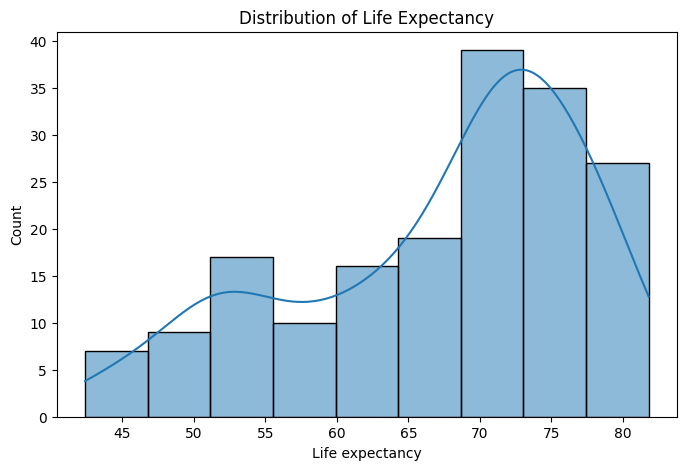

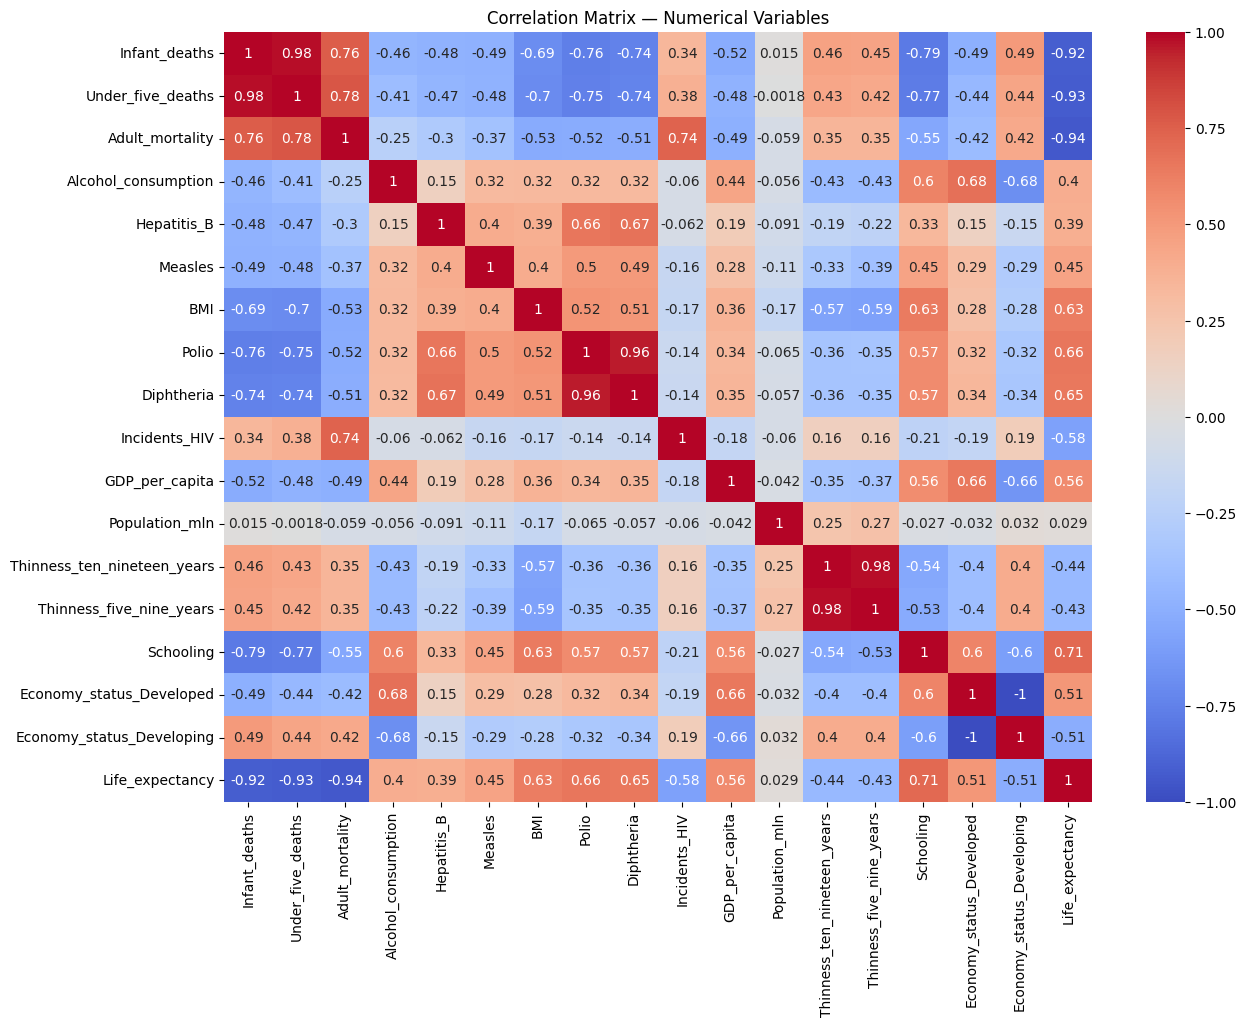

In [3]:
df = df[df['Year'] == 2003]  #This project focuses only on year 2003.
df=df.drop(columns="Year")

# Summary statistics
display(df.describe().T)

# Unique values in categorical variables
print("Countries:", df["Country"].nunique())
print("Regions:", df["Region"].nunique())

# Histogram of target distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["Life_expectancy"], kde=True) # Adding Kernel Density Estimate
plt.title("Distribution of Life Expectancy")
plt.xlabel("Life expectancy")
plt.show()

# Correlation heatmap for numerical variables
plt.figure(figsize=(14, 10))
corr = df.select_dtypes(include=np.number).corr() #Includes integer and float columns
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True)
plt.title("Correlation Matrix — Numerical Variables")
plt.show()


## Define predictors and target

`Life_expectancy` is the response.

`Country` is excluded from the model. `Region` is retained as the categorical geographic variable.

The two economy-status indicator columns are represented by a single binary variable to avoid perfect linear dependence with an intercept.


In [4]:
# Create a single economy-status indicator
# 1 = Developing, 0 = Developed
df["Economy_status"] = df["Economy_status_Developing"]

# Predictor columns
target = "Life_expectancy"


numeric_features = ["Infant_deaths",
    "Alcohol_consumption",
    "Hepatitis_B",
    "Measles",
    "BMI",
    "Polio",
    "Diphtheria",
    "Incidents_HIV",
    "GDP_per_capita",
    "Population_mln",
    "Thinness_ten_nineteen_years",
    "Thinness_five_nine_years",
    "Schooling",
    "Economy_status"
]

categorical_features = ["Region"]

In [5]:
X = df[numeric_features + categorical_features]
y = df[target]

# 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])


numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("onehot", OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

Training observations: 143
Testing observations: 36


# Multiple Linear Regression (OLS)

OLS is used as the baseline model. The same preprocessing is used for the regularized models so that the comparison is fair.


In [6]:
ols_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

ols_pipeline.fit(X_train, y_train)

y_pred_ols = ols_pipeline.predict(X_test)

ols_r2 = r2_score(y_test, y_pred_ols)
ols_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ols))
ols_mae = mean_absolute_error(y_test, y_pred_ols)

print("OLS Test R²       :", round(ols_r2, 4))
print("OLS Test RMSE     :", round(ols_rmse, 4))
print("OLS Test MAE      :", round(ols_mae, 4))


OLS Test R²       : 0.9253
OLS Test RMSE     : 2.6654
OLS Test MAE      : 2.0682


# Linear Regression Assumption Checks

The following assumptions/diagnostics are examined:

- **Linearity:** residuals versus fitted values.
- **Normality of residuals:** Q-Q plot and Shapiro-Wilk test on a sample when necessary.
- **Homoskedasticity:** residuals versus fitted values and Breusch-Pagan test.
- **Independence:** Durbin-Watson statistic.
- **Multicollinearity:** VIF.
- **Influential observations:** Cook's distance.



In [7]:
# Extract the transformed design matrix and residuals
X_train_transformed = ols_pipeline.named_steps["preprocessor"].transform(X_train)
y_train_pred_ols = ols_pipeline.predict(X_train)

residuals = y_train - y_train_pred_ols
fitted = y_train_pred_ols

print("Training residual mean:", residuals.mean())
print("Training residual SD:", residuals.std())


Training residual mean: -3.7266227400005255e-15
Training residual SD: 2.276196528656974


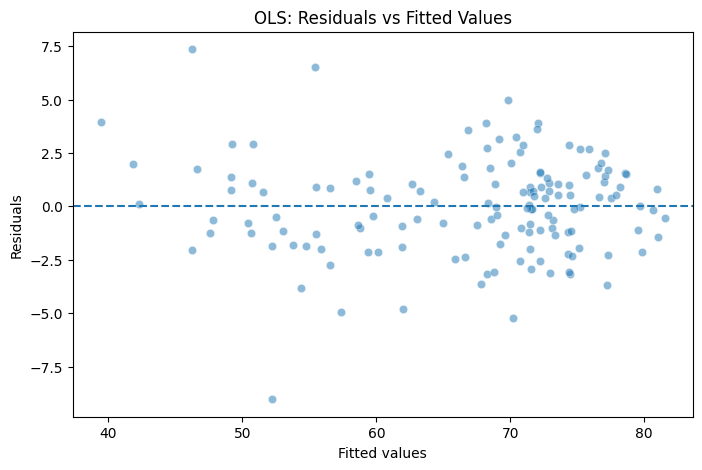

In [8]:
# Linearity: Residuals vs Fitted

plt.figure(figsize=(8, 5))
sns.scatterplot(x=fitted, y=residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("OLS: Residuals vs Fitted Values")
plt.show()


In [9]:
# Fit an equivalent OLS model in statsmodels on the transformed  #Since statsmodels provides get_influence()
# training matrix solely for influence diagnostics.

X_sm = sm.add_constant(X_train_transformed)
ols_sm = sm.OLS(y_train, X_sm).fit()

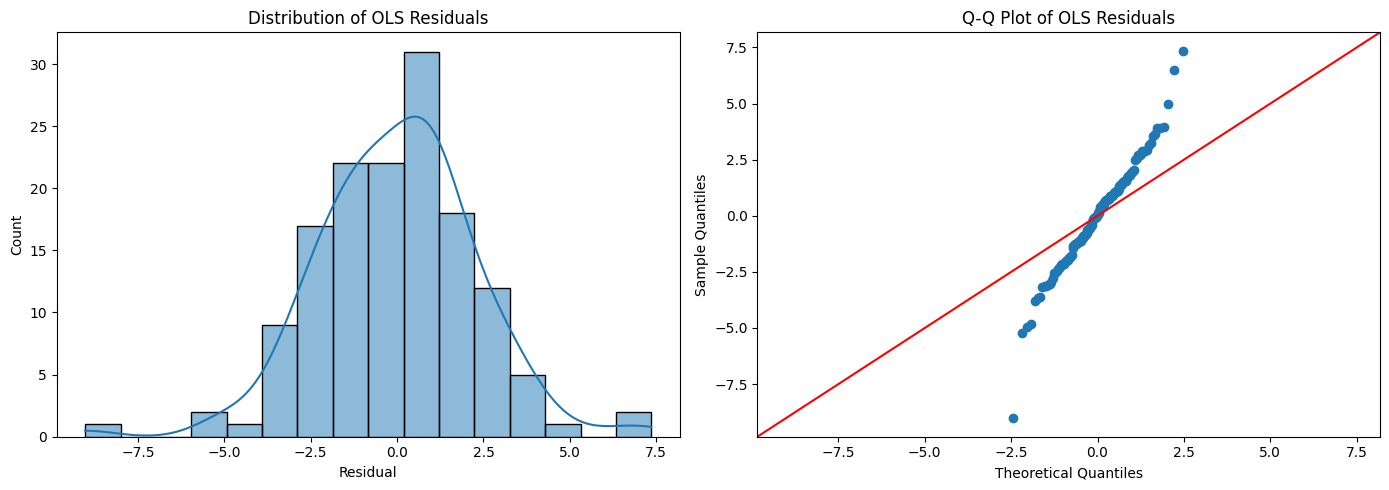

Shapiro-Wilk statistic: 0.9816
Shapiro-Wilk p-value : 0.0511261
Result: do not reject normality at the 5% level.


In [10]:
# Normality: Histogram + Q-Q plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].set_title("Distribution of OLS Residuals")
axes[0].set_xlabel("Residual")

sm.qqplot(residuals, line="45", ax=axes[1])
axes[1].set_title("Q-Q Plot of OLS Residuals")

plt.tight_layout()
plt.show()

# Shapiro-Wilk can be overly sensitive with large samples.
# Use at most 5000 observations.
shapiro_sample = residuals.sample(
    min(5000, len(residuals)),
    random_state=42
)


shapiro_stat, shapiro_p = stats.shapiro(shapiro_sample)

print("Shapiro-Wilk statistic:", round(shapiro_stat, 4))
print("Shapiro-Wilk p-value :", f"{shapiro_p:.6g}")

if shapiro_p < 0.05:
    print("Result: reject normality at the 5% level.")
else:
    print("Result: do not reject normality at the 5% level.")


In [11]:
# Homoskedasticity: Breusch-Pagan test

# Add constant for statsmodels diagnostic
X_bp = sm.add_constant(X_train_transformed)

bp_lm, bp_lm_pvalue, bp_fvalue, bp_f_pvalue = het_breuschpagan(
    residuals,
    X_bp
)

print("Breusch-Pagan LM statistic :", round(bp_lm, 4))
print("Breusch-Pagan LM p-value   :", f"{bp_lm_pvalue:.6g}")
print("Breusch-Pagan F statistic  :", round(bp_fvalue, 4))
print("Breusch-Pagan F p-value    :", f"{bp_f_pvalue:.6g}")

if bp_lm_pvalue < 0.05:
    print("Result: evidence of heteroskedasticity at the 5% level.")
else:
    print("Result: no significant evidence of heteroskedasticity at the 5% level.")


Breusch-Pagan LM statistic : 30.5221
Breusch-Pagan LM p-value   : 0.106318
Breusch-Pagan F statistic  : 1.4801
Breusch-Pagan F p-value    : 0.0935584
Result: no significant evidence of heteroskedasticity at the 5% level.


In [12]:
# Independence: Durbin-Watson + Breusch-Godfrey

from statsmodels.stats.diagnostic import acorr_breusch_godfrey

dw = durbin_watson(residuals)
print("Durbin-Watson statistic:", round(dw, 4))

bg_lm, bg_lm_pvalue, bg_fvalue, bg_f_pvalue = acorr_breusch_godfrey(ols_sm, nlags=1)

print("Breusch-Godfrey LM statistic :", round(bg_lm, 4))
print("Breusch-Godfrey LM p-value   :", f"{bg_lm_pvalue:.6g}")

if bg_lm_pvalue < 0.05:
    print("Result: evidence of residual autocorrelation at the 5% level.")
else:
    print("Result: no significant evidence of residual autocorrelation at the 5% level.")

Durbin-Watson statistic: 1.6965
Breusch-Godfrey LM statistic : 3.1052
Breusch-Godfrey LM p-value   : 0.0780403
Result: no significant evidence of residual autocorrelation at the 5% level.


In [13]:
# Multicollinearity: VIF

# VIF is evaluated on the transformed training design matrix.
# One-hot encoding has already removed one category per categorical variable.

feature_names = ols_pipeline.named_steps["preprocessor"].get_feature_names_out()

vif_df = pd.DataFrame({
    "Feature": feature_names,
    "VIF": [
        variance_inflation_factor(X_train_transformed, i)
        for i in range(X_train_transformed.shape[1])
    ]
}).sort_values("VIF", ascending=False)

display(vif_df)

print("\nCommon rule of thumb:")
print("VIF < 5   : usually acceptable")
print("VIF 5-10  : potentially problematic")
print("VIF > 10  : strong multicollinearity")


,Feature,VIF
11,num__Thinness_five_nine_years,26.484114
10,num__Thinness_ten_nineteen_years,24.199433
5,num__Polio,15.266349
6,num__Diphtheria,13.700954
0,num__Infant_deaths,6.426534
13,num__Economy_status,6.013096
16,cat__Region_European Union,5.333949
12,num__Schooling,4.832846
4,num__BMI,4.139345
1,num__Alcohol_consumption,2.952350



Common rule of thumb:
VIF < 5   : usually acceptable
VIF 5-10  : potentially problematic
VIF > 10  : strong multicollinearity


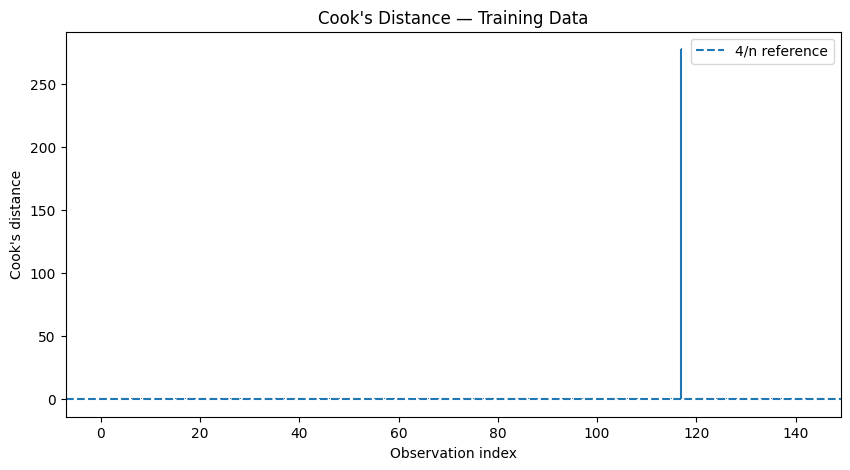

Maximum Cook's distance: 277.5096
Observations above 4/n: 10


In [14]:
# Influential observations: Cook's Distance

influence = ols_sm.get_influence()
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(10, 5))
plt.stem(
    np.arange(len(cooks_d)),
    cooks_d,
    markerfmt=",",
    basefmt=" "
)
plt.axhline(4 / len(cooks_d), linestyle="--",
            label="4/n reference")
plt.xlabel("Observation index")
plt.ylabel("Cook's distance")
plt.title("Cook's Distance — Training Data")
plt.legend()
plt.show()

print("Maximum Cook's distance:", round(cooks_d.max(), 4))
print("Observations above 4/n:",
      int(np.sum(cooks_d > 4 / len(cooks_d))))


In [15]:
influential_idx = np.where(cooks_d > 4 / len(cooks_d))[0]
top_idx = np.argmax(cooks_d)

print("Flagged indices:", influential_idx)
print("Most influential observation:", top_idx, "Cook's D =", cooks_d[top_idx])

# Map back to the actual training rows to see which countries/years they are
X_train.iloc[influential_idx]

Flagged indices: [  0  11  24  51  55  91 103 117 121 142]
Most influential observation: 117 Cook's D = 277.5095697004356


,Infant_deaths,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status,Region
2618,6.3,4.39,99,78,24.8,98,72,0.13,4419,11.23,3.5,3.3,9.8,1,Central America and Caribbean
2326,12.9,11.32,94,96,25.9,97,96,0.08,6370,144.65,2.6,2.8,11.4,1,Rest of Europe
2723,14.1,1.96,74,14,26.6,74,74,0.02,6517,4.39,4.8,4.7,7.5,1,Middle East
681,50.4,1.96,70,64,23.4,70,68,10.27,1291,11.98,9.8,9.9,6.8,1,Africa
436,7.8,11.17,56,98,25.9,53,50,0.10,3139,9.80,2.5,2.6,9.1,1,Rest of Europe
757,73.0,0.44,75,64,20.1,55,55,0.05,934,0.95,12.1,12.1,3.0,1,Oceania
2259,48.4,7.32,71,52,26.4,70,69,11.87,5203,46.72,13.5,16.1,8.8,1,Africa
1505,5.3,7.70,14,84,26.5,88,91,0.10,36024,31.64,0.5,0.4,11.7,0,North America
2211,104.3,4.23,58,64,23.2,49,35,3.50,536,3.08,8.7,8.7,3.7,1,Africa
1686,69.8,5.62,90,99,25.7,87,85,20.22,2662,1.02,8.2,8.4,3.4,1,Africa


In [16]:
# Sensitivity check: remove training observation at positional
# index 117, refit OLS, and compare against the original OLS
# (fully self-contained — does not touch/reuse shared objects)

remove_idx = 117

def make_ols_pipeline():
    prep = ColumnTransformer([
        ("num", Pipeline([("scaler", StandardScaler())]), numeric_features),
        ("cat", Pipeline([("onehot", OneHotEncoder(
            drop="first", handle_unknown="ignore", sparse_output=False
        ))]), categorical_features)
    ])
    return Pipeline([("preprocessor", prep), ("model", LinearRegression())])

ols_pipeline_orig = make_ols_pipeline()
ols_pipeline_orig.fit(X_train, y_train)

y_pred_ols_orig = ols_pipeline_orig.predict(X_test)
ols_r2_orig  = r2_score(y_test, y_pred_ols_orig)
ols_rmse_orig = np.sqrt(mean_squared_error(y_test, y_pred_ols_orig))
ols_mae_orig  = mean_absolute_error(y_test, y_pred_ols_orig)

# ---- Build reduced training set and fit a SEPARATE pipeline ----
mask = np.ones(len(X_train), dtype=bool)
mask[remove_idx] = False
X_train_sub = X_train.iloc[mask]
y_train_sub = y_train.iloc[mask]

print("Removed observation (index 117):")
display(X_train.iloc[[remove_idx]])

ols_pipeline_sub = make_ols_pipeline()
ols_pipeline_sub.fit(X_train_sub, y_train_sub)

y_pred_ols_sub = ols_pipeline_sub.predict(X_test)
ols_r2_sub  = r2_score(y_test, y_pred_ols_sub)
ols_rmse_sub = np.sqrt(mean_squared_error(y_test, y_pred_ols_sub))
ols_mae_sub  = mean_absolute_error(y_test, y_pred_ols_sub)

# ---- Metric comparison ----
print("\n--- OLS: original vs. observation 117 removed ---")
print(f"{'Metric':<12}{'Original':>12}{'Without point':>16}{'Change':>12}")
print(f"{'Test R2':<12}{ols_r2_orig:>12.4f}{ols_r2_sub:>16.4f}{ols_r2_sub - ols_r2_orig:>+12.4f}")
print(f"{'Test RMSE':<12}{ols_rmse_orig:>12.4f}{ols_rmse_sub:>16.4f}{ols_rmse_sub - ols_rmse_orig:>+12.4f}")
print(f"{'Test MAE':<12}{ols_mae_orig:>12.4f}{ols_mae_sub:>16.4f}{ols_mae_sub - ols_mae_orig:>+12.4f}")

# ---- Coefficient comparison, aligned by feature NAME (not position) ----
feat_names_orig = ols_pipeline_orig.named_steps["preprocessor"].get_feature_names_out()
feat_names_sub  = ols_pipeline_sub.named_steps["preprocessor"].get_feature_names_out()

coef_orig_s = pd.Series(ols_pipeline_orig.named_steps["model"].coef_, index=feat_names_orig, name="Original")
coef_sub_s  = pd.Series(ols_pipeline_sub.named_steps["model"].coef_, index=feat_names_sub, name="Without_point")

coef_shift = pd.concat([coef_orig_s, coef_sub_s], axis=1)
coef_shift["Abs_change"] = (coef_shift["Without_point"] - coef_shift["Original"]).abs()
coef_shift = coef_shift.sort_values("Abs_change", ascending=False)

missing_features = coef_shift[coef_shift["Without_point"].isna() | coef_shift["Original"].isna()].index.tolist()
if missing_features:
    print("\nFeature columns present in only one of the two fits (category dropped/added):")
    print(missing_features)

print("\nTop 5 coefficients that shifted the most:")
display(coef_shift.dropna().head(5))

Removed observation (index 117):


,Infant_deaths,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status,Region
1505,5.3,7.7,14,84,26.5,88,91,0.1,36024,31.64,0.5,0.4,11.7,0,North America



--- OLS: original vs. observation 117 removed ---
Metric          Original   Without point      Change
Test R2           0.9253          0.9267     +0.0014
Test RMSE         2.6654          2.6397     -0.0257
Test MAE          2.0682          2.0682     +0.0000

Feature columns present in only one of the two fits (category dropped/added):
['cat__Region_North America']

Top 5 coefficients that shifted the most:


,Original,Without_point,Abs_change
num__Economy_status,-2.195517,-2.166308,0.029209
num__Hepatitis_B,-0.292388,-0.276698,0.015690
num__Incidents_HIV,-2.904378,-2.913263,0.008885
num__GDP_per_capita,0.872961,0.868002,0.004959
num__Schooling,-0.657085,-0.654248,0.002837


**Note:** The point with the highest Cook's distance (277.5, observation 117) was investigated but retained — removing it changed test R² by only +0.0014 and RMSE by -0.0257, showing it does not materially affect the model's predictive performance despite its high influence on the training fit. All 10 flagged points were therefore kept in the final model to avoid discarding real data without an accuracy-based justification.

# Principal Component Regression (PCR)

PCA is added **after the train/test split** so that the principal components are learned from the training data only.

The steps are:

1. Fit the existing preprocessing pipeline on the training set.
2. Standardize the predictors.
3. Fit PCA on the **training data only**.
4. Retain enough principal components to explain **95% of the training variance**.
5. Fit Linear Regression using those principal components.
6. Transform the untouched test set using the already-fitted preprocessing and PCA.
7. Evaluate PCR on the same test set used by OLS, Ridge and Lasso.

This avoids data leakage and also shows whether dimensionality reduction can maintain predictive performance while reducing the number of dimensions.


In [17]:
# PCA + Linear Regression (Principal Component Regression)

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Fit preprocessing on training data only

pca_preprocessor = preprocessor.fit(X_train, y_train)

X_train_processed = pca_preprocessor.transform(X_train)
X_test_processed = pca_preprocessor.transform(X_test)


# PCA
# Keep enough PCs to explain 95% of training variance

pca = PCA(
    n_components=0.95,
    svd_solver="full",
    random_state=42
)

# Fit PCA ONLY on training data
# Each principal component is a particular combination of variables.
X_train_pca = pca.fit_transform(X_train_processed)

# Transform test data using the PCA fitted on training data
# Use those same combinations to transform the test observations.

X_test_pca = pca.transform(X_test_processed)

print("Original transformed features:",
      X_train_processed.shape[1])

print("Number of principal components retained:",
      X_train_pca.shape[1])

print("Variance explained by retained PCs:",
      round(pca.explained_variance_ratio_.sum(), 4))


# Fit Linear Regression on principal components
pcr_model = LinearRegression()
pcr_model.fit(X_train_pca, y_train)


# Test predictions
y_pred_pcr = pcr_model.predict(X_test_pca)

# Evaluation metrics
pcr_r2 = r2_score(y_test, y_pred_pcr)
pcr_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_pcr)
)

pcr_mae = mean_absolute_error(
    y_test, y_pred_pcr
)


# Print results

print("\nPCR Test R²       :", round(pcr_r2, 4))
print("PCR Test RMSE     :", round(pcr_rmse, 4))
print("PCR Test MAE      :", round(pcr_mae, 4))

Original transformed features: 22
Number of principal components retained: 11
Variance explained by retained PCs: 0.9602

PCR Test R²       : 0.8798
PCR Test RMSE     : 3.3804
PCR Test MAE      : 2.8571


,PC,Explained_Variance,Cumulative_Variance
0,1,0.421487,0.421487
1,2,0.118150,0.539637
2,3,0.100500,0.640137
3,4,0.072890,0.713027
4,5,0.056368,0.769395
5,6,0.045980,0.815376
6,7,0.041225,0.856601
7,8,0.036913,0.893514
8,9,0.028533,0.922047
9,10,0.019272,0.941320


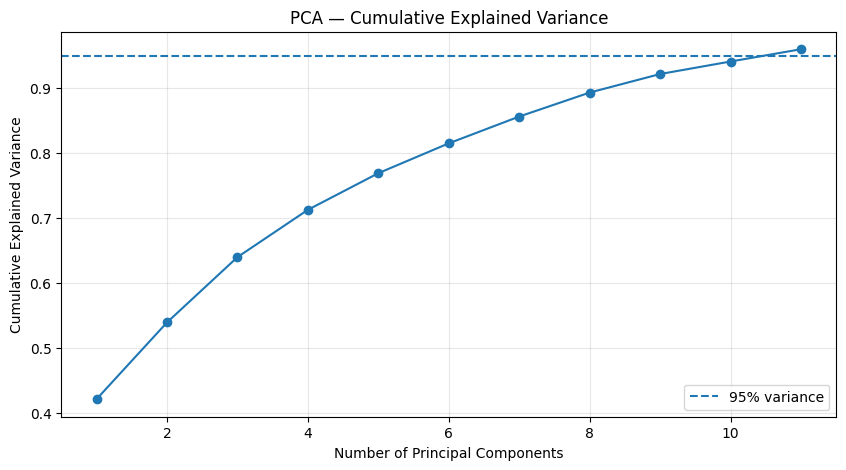

In [18]:
# PCA Explained Variance

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

pca_variance_table = pd.DataFrame({
    "PC": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "Explained_Variance": pca.explained_variance_ratio_,
    "Cumulative_Variance": cumulative_variance
})

display(pca_variance_table)

plt.figure(figsize=(10, 5))
plt.plot(
    np.arange(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)
plt.axhline(0.95, linestyle="--", label="95% variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA — Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 9. Ridge Regression

Ridge regression is sensitive to the scale of predictors, which is why the preprocessing pipeline standardizes numerical variables.

The regularization parameter `alpha` is selected using **3-fold cross-validation on the training data only**. The test set remains untouched.


In [19]:
# Ridge Regression with Hyperparameter Tuning

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold

# Create Ridge pipeline
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])


# Define alpha grid
alpha_grid = {
    "model__alpha": np.logspace(-4, 4, 100)
}

# 3-Fold Cross-Validation
cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Grid Search
# Optimize alpha based on CV RMSE
ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=alpha_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

ridge_search.fit(X_train, y_train)


#  Best Ridge model
best_ridge_alpha = ridge_search.best_params_["model__alpha"]
ridge_model = ridge_search.best_estimator_

#  Test predictions
y_pred_ridge = ridge_model.predict(X_test)


#  Evaluation metrics
ridge_r2 = r2_score(
    y_test,
    y_pred_ridge
)

ridge_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_ridge)
)

ridge_mae = mean_absolute_error(
    y_test,
    y_pred_ridge
)


#  Print results
print("Best Ridge alpha :", best_ridge_alpha)
print("Ridge Test R²    :", round(ridge_r2, 4))
print("Ridge Test RMSE  :", round(ridge_rmse, 4))
print("Ridge Test MAE   :", round(ridge_mae, 4))

Best Ridge alpha : 3.351602650938848
Ridge Test R²    : 0.926
Ridge Test RMSE  : 2.6533
Ridge Test MAE   : 2.1618


# Lasso Regression

Lasso performs both regularization and variable selection by shrinking some coefficients exactly to zero.

Again, `alpha` is selected using 3-fold cross-validation on the training set.


In [20]:
# Lasso Regression with Hyperparameter Tuning

from sklearn.linear_model import Lasso

#  Create Lasso pipeline
lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=100000))
])


#  Grid Search with 3-Fold Cross-Validation
lasso_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=alpha_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

lasso_search.fit(X_train, y_train)


#  Best Lasso model
best_lasso_alpha = lasso_search.best_params_["model__alpha"]
lasso_model = lasso_search.best_estimator_


#  Test predictions
y_pred_lasso = lasso_model.predict(X_test)


#  Evaluation metrics
lasso_r2 = r2_score(
    y_test,
    y_pred_lasso
)

lasso_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_lasso)
)

lasso_mae = mean_absolute_error(
    y_test,
    y_pred_lasso
)



#  Print results
print("Best Lasso alpha :", best_lasso_alpha)
print("Lasso Test R²    :", round(lasso_r2, 4))
print("Lasso Test RMSE  :", round(lasso_rmse, 4))
print("Lasso Test MAE   :", round(lasso_mae, 4))

Best Lasso alpha : 0.521400828799969
Lasso Test R²    : 0.9212
Lasso Test RMSE  : 2.7377
Lasso Test MAE   : 2.1813


# Compare OLS, Ridge, Lasso and PCR

All three models are evaluated on the **same untouched test set**.

- Higher R² is better.
- Lower RMSE is better.
- Lower MAE is better.

The CV-selected `alpha` values are reported for Ridge and Lasso.


In [21]:
# Final Model Comparison

comparison = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso", "PCR"],

    "Test R²": [
        ols_r2,
        ridge_r2,
        lasso_r2,
        pcr_r2
    ],

    "Test RMSE": [
        ols_rmse,
        ridge_rmse,
        lasso_rmse,
        pcr_rmse
    ],

    "Test MAE": [
        ols_mae,
        ridge_mae,
        lasso_mae,
        pcr_mae
    ],

    "Tuned alpha": [
        "—",
        best_ridge_alpha,
        best_lasso_alpha,
        "—"
    ],

    "PCA components": [
        "—",
        "—",
        "—",
        pca.n_components_
    ],

    "PCA variance retained": [
        "—",
        "—",
        "—",
        pca.explained_variance_ratio_.sum()
    ]
})


# Sort by Test R²

comparison = comparison.sort_values(
    "Test R²", ascending=False
).reset_index(drop=True)


# Display comparison table

display(
    comparison.style.format({
        "Test R²": "{:.4f}",
        "Test RMSE": "{:.4f}",
        "Test MAE": "{:.4f}",
        "PCA variance retained":
            lambda x: "—" if x == "—" else f"{x:.2%}"
    })
)


# Best model based on Test R²

best_model = comparison.iloc[0]["Model"]

print(f"\nBest model by test R²: {best_model}")

,Model,Test R²,Test RMSE,Test MAE,Tuned alpha,PCA components,PCA variance retained
0,Ridge,0.9260,2.6533,2.1618,3.351603,—,—
1,OLS,0.9253,2.6654,2.0682,—,—,—
2,Lasso,0.9212,2.7377,2.1813,0.521401,—,—
3,PCR,0.8798,3.3804,2.8571,—,11,96.02%



Best model by test R²: Ridge


In [22]:
# Train R² and Train Adjusted R² for OLS, Ridge, Lasso, PCR

def adj_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

n_train = len(y_train)

# ---- OLS ----
y_train_pred_ols = ols_pipeline.predict(X_train)
ols_r2_train = r2_score(y_train, y_train_pred_ols)
p_ols = ols_pipeline.named_steps["preprocessor"].transform(X_train).shape[1]
ols_adj_r2_train = adj_r2(ols_r2_train, n_train, p_ols)

# ---- Ridge ----
y_train_pred_ridge = ridge_model.predict(X_train)
ridge_r2_train = r2_score(y_train, y_train_pred_ridge)
p_ridge = ridge_model.named_steps["preprocessor"].transform(X_train).shape[1]
ridge_adj_r2_train = adj_r2(ridge_r2_train, n_train, p_ridge)

# ---- Lasso ----
y_train_pred_lasso = lasso_model.predict(X_train)
lasso_r2_train = r2_score(y_train, y_train_pred_lasso)
lasso_coefficients = lasso_model.named_steps["model"].coef_
p_lasso = int(np.sum(np.abs(lasso_coefficients) > 1e-6))  # nonzero coefficients only
lasso_adj_r2_train = adj_r2(lasso_r2_train, n_train, p_lasso)

# ---- PCR ----
y_train_pred_pcr = pcr_model.predict(X_train_pca)
pcr_r2_train = r2_score(y_train, y_train_pred_pcr)
p_pcr = X_train_pca.shape[1]  # number of retained principal components
pcr_adj_r2_train = adj_r2(pcr_r2_train, n_train, p_pcr)


# Train vs Test comparison
train_test_comparison = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso", "PCR"],

    "Train R²": [ols_r2_train, ridge_r2_train, lasso_r2_train, pcr_r2_train],
    "Train Adjusted R²": [ols_adj_r2_train, ridge_adj_r2_train, lasso_adj_r2_train, pcr_adj_r2_train],
    "Train p": [p_ols, p_ridge, p_lasso, p_pcr],

    "Test R²": [ols_r2, ridge_r2, lasso_r2, pcr_r2],
    "Test RMSE": [ols_rmse, ridge_rmse, lasso_rmse, pcr_rmse],
    "Test MAE": [ols_mae, ridge_mae, lasso_mae, pcr_mae],
})

train_test_comparison["R² Gap (Train - Test)"] = (
    train_test_comparison["Train R²"] - train_test_comparison["Test R²"]
)

train_test_comparison = train_test_comparison.sort_values(
    "Test R²", ascending=False
).reset_index(drop=True)

display(
    train_test_comparison.style.format({
        "Train R²": "{:.4f}",
        "Train Adjusted R²": "{:.4f}",
        "Test R²": "{:.4f}",
        "Test RMSE": "{:.4f}",
        "Test MAE": "{:.4f}",
        "R² Gap (Train - Test)": "{:+.4f}",
    })
)

,Model,Train R²,Train Adjusted R²,Train p,Test R²,Test RMSE,Test MAE,R² Gap (Train - Test)
0,Ridge,0.9469,0.9372,22,0.9260,2.6533,2.1618,+0.0209
1,OLS,0.9494,0.9402,22,0.9253,2.6654,2.0682,+0.0241
2,Lasso,0.9263,0.9247,3,0.9212,2.7377,2.1813,+0.0051
3,PCR,0.9023,0.8941,11,0.8798,3.3804,2.8571,+0.0224


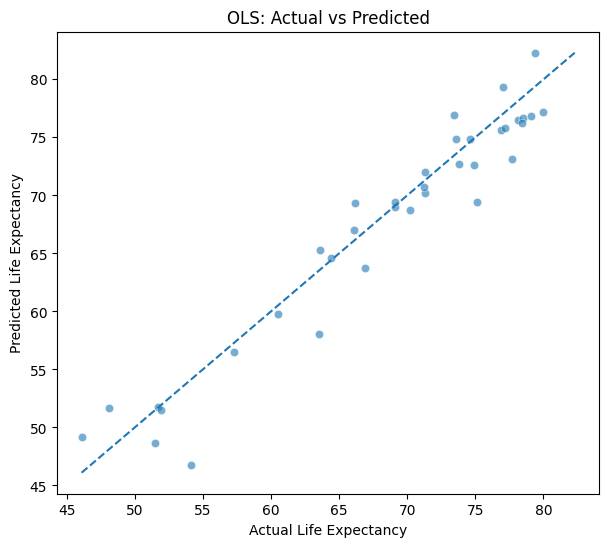

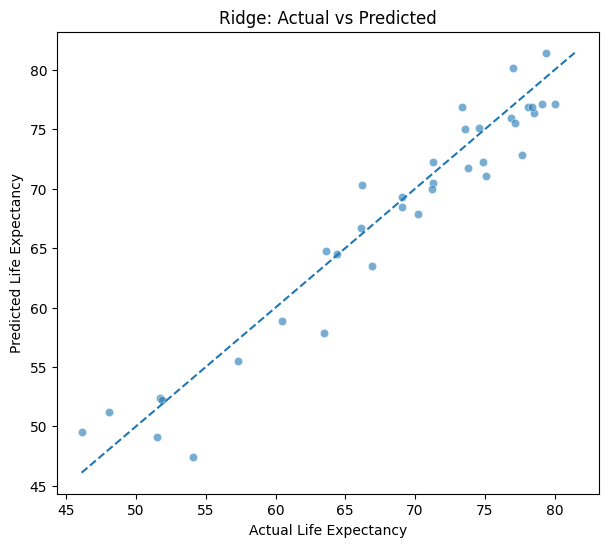

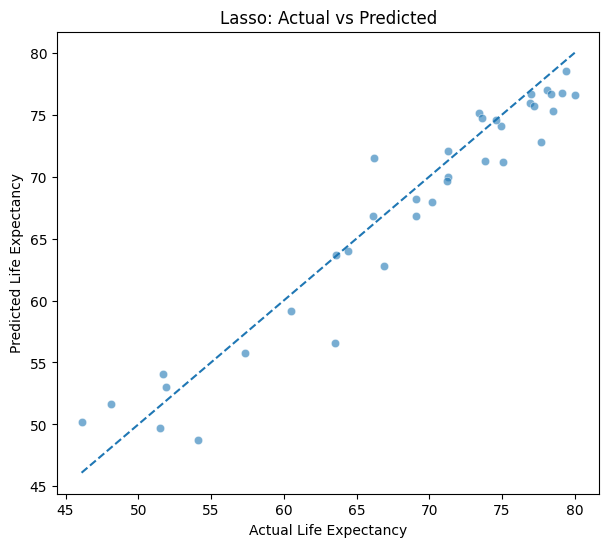

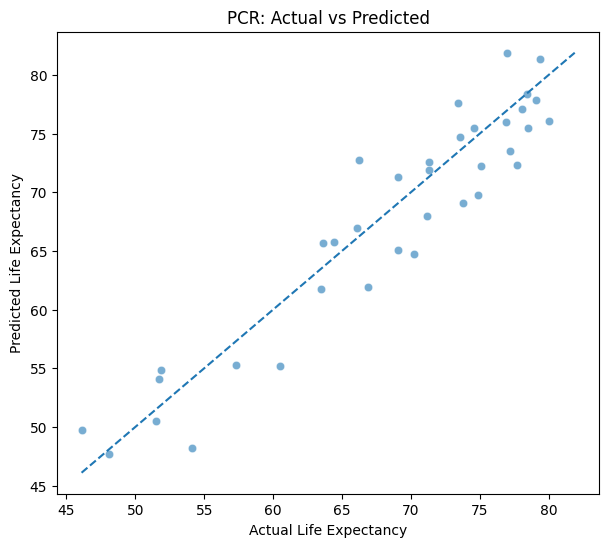

In [23]:
# Actual vs Predicted

predictions = {
    "OLS": y_pred_ols,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "PCR": y_pred_pcr
}

for name, pred in predictions.items():
    plt.figure(figsize=(7, 6))
    sns.scatterplot(x=y_test, y=pred, alpha=0.6)

    min_val = min(y_test.min(), pred.min())
    max_val = max(y_test.max(), pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel("Actual Life Expectancy")
    plt.ylabel("Predicted Life Expectancy")
    plt.title(f"{name}: Actual vs Predicted")
    plt.show()


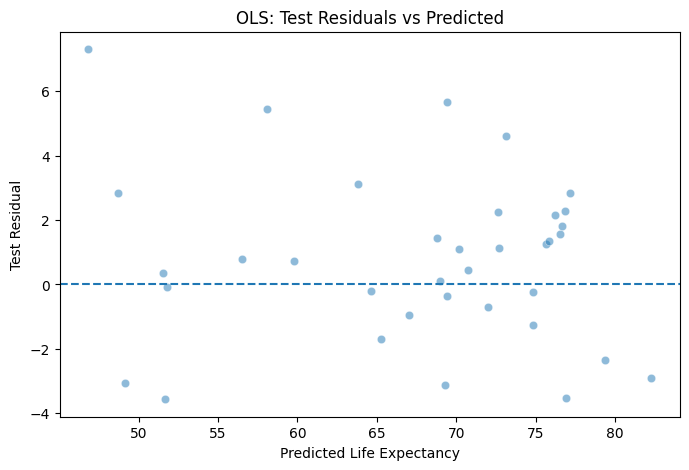

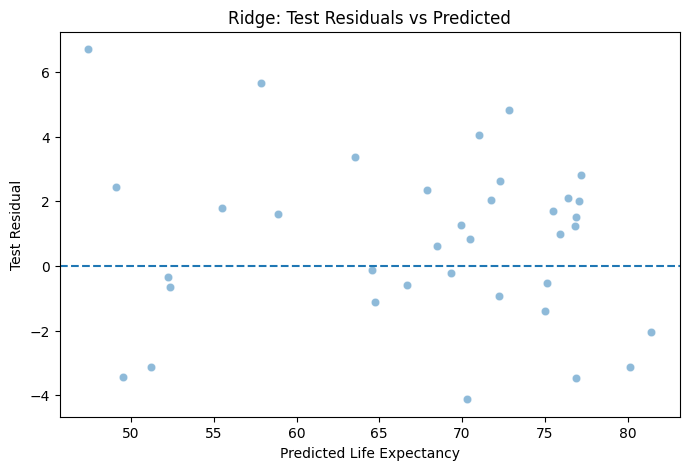

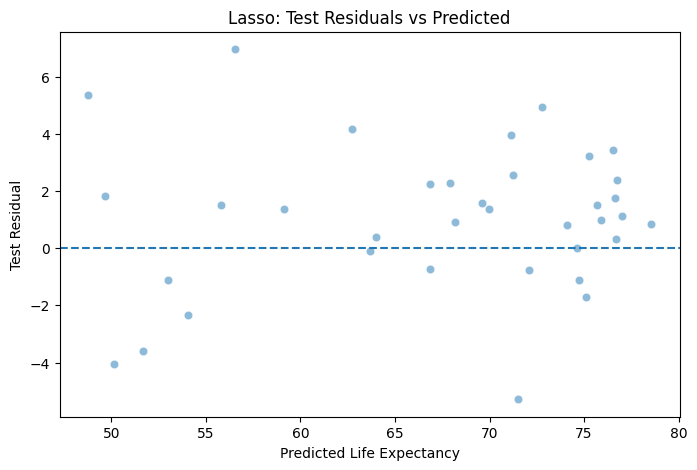

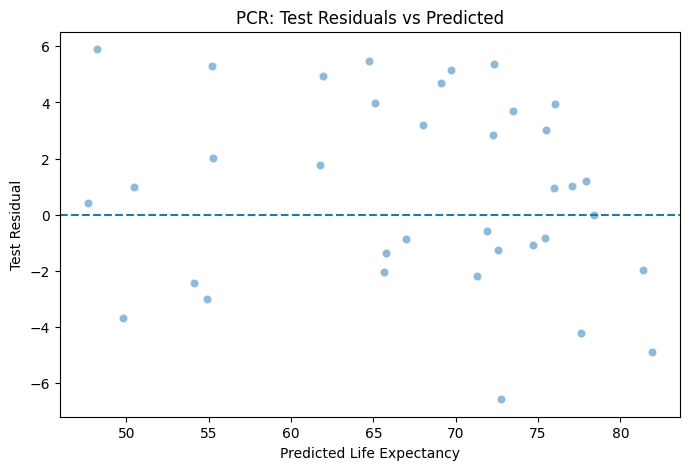

In [24]:
# Residual comparison

for name, pred in predictions.items():
    residual = y_test - pred

    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=pred, y=residual, alpha=0.5)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted Life Expectancy")
    plt.ylabel("Test Residual")
    plt.title(f"{name}: Test Residuals vs Predicted")
    plt.show()
